In [1]:
import pandas as pd

In [2]:
import seaborn as sbn
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("bisiklet_fiyatlari.xlsx")

In [4]:
df.head()

,Fiyat,BisikletOzellik1,BisikletOzellik2
0,807.673876,1749.628226,1749.590668
1,959.227520,1748.007826,1751.824206
2,718.020033,1750.122967,1747.977026
3,945.668885,1749.916440,1750.771646
4,955.542968,1750.780519,1750.592430


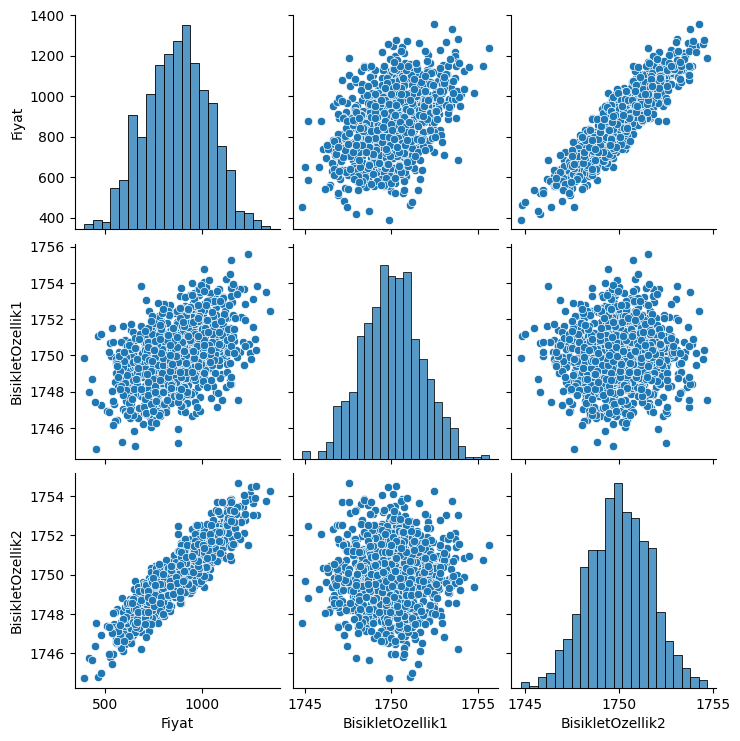

In [5]:
sbn.pairplot(df)

## Veriyi Test / Train olarak ikiye ayırmak

In [6]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.model_selection import train_test_split   # test modeli ile karsılastırıyor gibi bir sey

In [9]:
train_test_split

<function sklearn.model_selection._split.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)>

In [10]:
# y = wx + b 
# y -> label (fiyat)
# x -> feature (özellik)

y = df["Fiyat"].values
x = df[["BisikletOzellik1","BisikletOzellik2"]].values

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.33, random_state=15)

In [11]:
x_train.shape   #670 veri 2 tane dizi gibi yani matris

(670, 2)

In [12]:
x_test.shape #330 veri

(330, 2)

In [13]:
# scaling boyut degistirme büyültmek ya da küçültmek

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()

In [16]:
scaler.fit(x_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [17]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)    # degerleri 0-1 arasına getirir

In [18]:
import tensorflow as tf

In [19]:
from tensorflow.keras.models import Sequential   # modelimizin sınıfı 
from tensorflow.keras.layers import Dense        # modelin içindeki katmanlar (katmanın içinde de nöronlar var)

In [20]:
model = Sequential()
model.add(Dense(4,activation="relu"))  #4 tane nöron olucak
model.add(Dense(4,activation="relu"))
model.add(Dense(4,activation="relu")) # toplam 3 katman hepsinde 4 nöron var 

model.add(Dense(1))

model.compile(
    optimizer="rmsprop",
    loss="mse",   
    metrics=["mae"]
    # sadece loss kullanıyoruz
)
#model.compile(optimizer = "rmsprop", loss="mae")  # yaptıgımız işlemleri birleştirip  hazır hale getirir compile 
#rmsprop en çok kullanılan model adam da var #mse regresyon çizgisi kullanıldı

In [21]:
model.fit(x_train,y_train,epochs=250)  # modeli egitme kodu y_trainle x_Traini egitiyoruz

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 795997.4375 - mae: 877.0391
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 795891.8125 - mae: 876.9796 
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 795806.2500 - mae: 876.9319 
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 795737.3125 - mae: 876.8936 
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 795671.6250 - mae: 876.8564 
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 795595.6250 - mae: 876.8142 
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 795511.1250 - mae: 876.7665 
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 795417.0000 - mae: 876.7135 
Epoch 9/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 795310.8750 - mae: 876.6540 
Epoch 10/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 795188.3750 - mae: 876.5847 
Epoch 11/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 795040.5625 - mae: 876.5015 
Epoch 12/250
21/21 ━━━━━━━━━━━━

In [22]:
loss = model.history.history["loss"]

<Axes: >

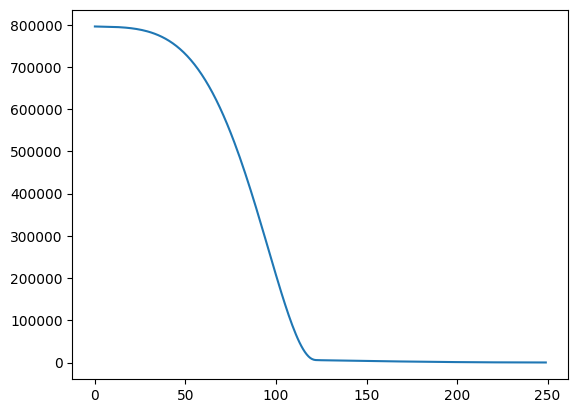

In [23]:
sbn.lineplot(x=range(len(loss)),y=loss)

In [24]:
trainLoss = model.evaluate(x_train,y_train, verbose=0)   #modelin kendi degerlendirmesi

In [25]:
testLoss = model.evaluate(x_test, y_test, verbose=0)

In [26]:
trainLoss

[98.88925170898438, 8.072820663452148]

In [27]:
testLoss

[91.49983215332031, 7.592884540557861]

In [28]:
testTahminleri = model.predict(x_test)   #predict tahmin 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [29]:
testTahminleri

array([[1075.0221 ],
       [ 631.99225],
       [ 877.9396 ],
       [ 897.7044 ],
       [ 903.18176],
       [ 467.2956 ],
       [ 932.3715 ],
       [ 991.533  ],
       [ 940.28033],
       [1015.7051 ],
       [ 755.8133 ],
       [ 917.71735],
       [ 949.36554],
       [1052.185  ],
       [1116.0519 ],
       [ 689.2037 ],
       [1124.5809 ],
       [ 660.9028 ],
       [1151.7994 ],
       [ 888.20654],
       [ 894.7551 ],
       [ 721.61646],
       [ 467.82886],
       [ 622.8388 ],
       [ 837.44684],
       [1087.3536 ],
       [ 720.63043],
       [ 762.75616],
       [ 876.8774 ],
       [ 776.03345],
       [ 465.0868 ],
       [ 786.8327 ],
       [ 734.499  ],
       [ 655.73737],
       [ 889.20245],
       [ 847.215  ],
       [1033.6868 ],
       [1022.7313 ],
       [ 847.47406],
       [ 865.5198 ],
       [ 762.16205],
       [1170.5027 ],
       [1094.3955 ],
       [1084.5674 ],
       [ 873.7213 ],
       [ 605.755  ],
       [1143.4441 ],
       [ 974.

In [30]:
tahminDf = pd.DataFrame(y_test,columns=["Gerçek Y"])

In [31]:
tahminDf

,Gerçek Y
0,1081.652164
1,622.675990
2,889.356810
3,902.826733
4,897.662404
...,...
325,1028.438035
326,789.934950
327,758.490486
328,1172.871659


In [32]:
testTahminleri = pd.Series(testTahminleri.reshape(330,))    # 330 boyutlu oldugu için gerçeky degerleri ona çevirdik

In [33]:
testTahminleri

0      1075.022095
1       631.992249
2       877.939575
3       897.704407
4       903.181763
          ...     
325    1011.981567
326     796.411560
327     770.263672
328    1162.042603
329     808.697693
Length: 330, dtype: float32

In [34]:
tahminDf = pd.concat([tahminDf,testTahminleri],axis=1)

In [35]:
tahminDf

,Gerçek Y,0
0,1081.652164,1075.022095
1,622.675990,631.992249
2,889.356810,877.939575
3,902.826733,897.704407
4,897.662404,903.181763
...,...,...
325,1028.438035,1011.981567
326,789.934950,796.411560
327,758.490486,770.263672
328,1172.871659,1162.042603


In [36]:
tahminDf.columns = ["Gerçek Y","Tahmin Y"]

In [37]:
tahminDf  # tahminler gerçege yakın çıkmış 

,Gerçek Y,Tahmin Y
0,1081.652164,1075.022095
1,622.675990,631.992249
2,889.356810,877.939575
3,902.826733,897.704407
4,897.662404,903.181763
...,...,...
325,1028.438035,1011.981567
326,789.934950,796.411560
327,758.490486,770.263672
328,1172.871659,1162.042603


<Axes: xlabel='Gerçek Y', ylabel='Tahmin Y'>

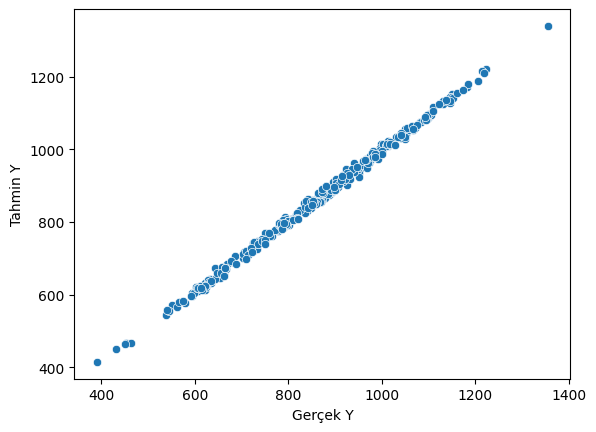

In [38]:
sbn.scatterplot(x= "Gerçek Y",y = "Tahmin Y",data=tahminDf)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
mean_absolute_error(tahminDf["Gerçek Y"], tahminDf["Tahmin Y"])

7.592884889550188

In [41]:
df.describe()

,Fiyat,BisikletOzellik1,BisikletOzellik2
count,1000.000000,1000.000000,1000.000000
mean,872.677801,1750.024800,1749.964733
std,164.124504,1.704531,1.659578
min,390.856887,1744.852108,1744.742389
25%,757.795031,1748.831119,1748.803186
50%,879.168705,1750.017350,1750.003926
75%,988.612778,1751.115765,1751.129414
max,1355.213745,1755.613884,1754.666038


In [42]:
yenibisikletOzellikleri = [[1751,1750]]

In [43]:
yenibisikletOzellikleri = scaler.transform(yenibisikletOzellikleri)

In [44]:
model.predict(yenibisikletOzellikleri)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[915.2445]], dtype=float32)

In [45]:
from tensorflow.keras.models import load_model

In [46]:
model.save("bisiklet_model.keras")

In [47]:
sonradanCagirilanModel = load_model("bisiklet_model.keras")

In [48]:
from tensorflow import keras

In [49]:
sonradanCagirilanModel.predict(yenibisikletOzellikleri)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[915.2445]], dtype=float32)